# Movie Review Sentiment Analysis

This notebook performs sentiment analysis on the IMDB Movie Review dataset. The project involves data collection, exploratory data analysis (EDA), text preprocessing, feature extraction using TF-IDF, and sentiment classification using various machine learning models including Logistic Regression, Random Forest, and a Neural Network with Sentence Embeddings. The goal is to predict whether a movie review is positive or negative.

# Dataset Collection and Loading

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 83.8MB/s]



In [3]:
!mkdir Dataset
!unzip imdb-dataset-of-50k-movie-reviews.zip -d Dataset

Archive:  imdb-dataset-of-50k-movie-reviews.zip
  inflating: Dataset/IMDB Dataset.csv  


# Reading The Data

In [4]:
import pandas as pd

df = pd.read_csv('/content/Dataset/IMDB Dataset.csv')

print(df)

                                                  review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative
49997  I am a Catholic taught in parochial elementary...  negative
49998  I'm going to have to disagree with the previou...  negative
49999  No one expects the Star Trek movies to be high...  negative

[50000 rows x 2 columns]


In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.shape

(50000, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [8]:
df.isnull().sum()

,0
review,0
sentiment,0


In [9]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 418


In [10]:
print("Shape Before:", df.shape)
df = df.drop_duplicates()
print("Shape After:", df.shape)

Shape Before: (50000, 2)
Shape After: (49582, 2)


In [11]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [12]:
df["sentiment"].value_counts()

,count
sentiment,
positive,24884
negative,24698


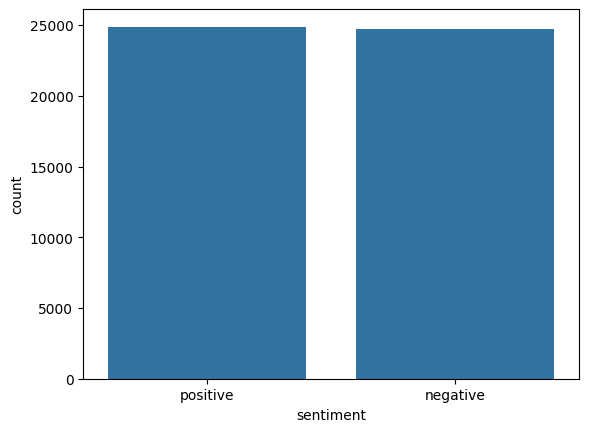

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.show()

# Text EDA

In [14]:
df['wordCount'] = df['review'].apply(lambda x: len(str(x).split()))

In [15]:
df['charCount'] = df['review'].apply(lambda x: len(str(x)))

In [16]:
df

,review,sentiment,wordCount,charCount
0,One of the other reviewers has mentioned that ...,positive,307,1761
1,A wonderful little production. <br /><br />The...,positive,162,998
2,I thought this was a wonderful way to spend ti...,positive,166,926
3,Basically there's a family where a little boy ...,negative,138,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,194,1008
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,112,642
49997,I am a Catholic taught in parochial elementary...,negative,230,1280
49998,I'm going to have to disagree with the previou...,negative,212,1234


In [17]:
print(df.describe())

          wordCount     charCount
count  49582.000000  49582.000000
mean     231.350167   1310.568230
std      171.542020    990.762238
min        4.000000     32.000000
25%      126.000000    699.000000
50%      173.000000    971.000000
75%      281.000000   1592.000000
max     2470.000000  13704.000000


**Do people write longer reviews when they dislike a movie?**                                                                                                             

**People Generally Write the Larger review then the Sentiment is Positive**

<Axes: xlabel='sentiment', ylabel='wordCount'>

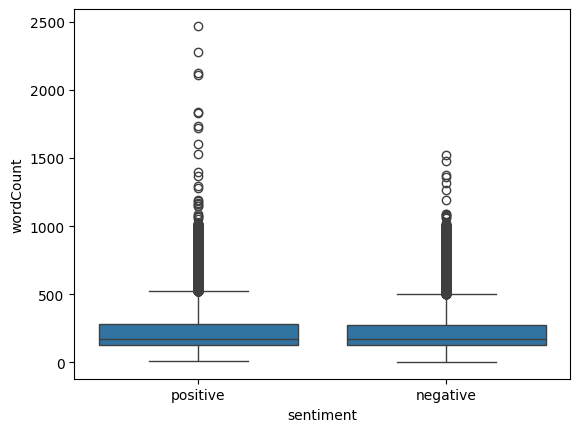

In [18]:
sns.boxplot(x='sentiment' , y='wordCount',data=df)

**counts the number of reviews containing HTML tags.**
**`na=False` treats missing (NaN) values as `False`**
**while checking the condition, preventing errors and ensuring consistent results.**


In [19]:
df['review'].str.contains('<', na=False).sum()

np.int64(28976)

In [20]:
from bs4 import BeautifulSoup

def remove_html_tags(text):
    return BeautifulSoup(text, "html.parser").get_text()

df['review'] = df['review'].apply(remove_html_tags)
df

,review,sentiment,wordCount,charCount
0,One of the other reviewers has mentioned that ...,positive,307,1761
1,A wonderful little production. The filming tec...,positive,162,998
2,I thought this was a wonderful way to spend ti...,positive,166,926
3,Basically there's a family where a little boy ...,negative,138,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1317
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,194,1008
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,112,642
49997,I am a Catholic taught in parochial elementary...,negative,230,1280
49998,I'm going to have to disagree with the previou...,negative,212,1234


In [21]:
# df['sentiment'] = df['sentiment'].map({'positive': 1,'negative': 0})
# Map 'positive' to 1 and 'negative' to 0 for the sentiment column
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [22]:
df.head()

,review,sentiment,wordCount,charCount
0,One of the other reviewers has mentioned that ...,1,307,1761
1,A wonderful little production. The filming tec...,1,162,998
2,I thought this was a wonderful way to spend ti...,1,166,926
3,Basically there's a family where a little boy ...,0,138,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,230,1317


In [23]:
df['review'] = df['review'].str.lower()

**check of data contain any urls**

In [24]:
df['review'].str.contains('http', na=False).sum()

np.int64(121)

**Removed**

In [25]:
import re

df['review'] = df['review'].apply(
    lambda x: re.sub(r'http\S+|www\S+', '', x)
)

In [26]:
df['review'].str.contains('http', na=False).sum()

np.int64(0)

**Removed special characters, numbers, and punctuation from the review text while retaining only alphabetic characters. Additionally, multiple spaces were replaced with a single space and leading/trailing spaces were removed to create clean and consistent text for further NLP preprocessing**.


In [27]:
import re

df['review'] = df['review'].apply(
    lambda x: re.sub(r'\s+', ' ', re.sub(r'[^a-zA-Z\s]', '', x)).strip()
)

**Removing Stopword**

**Removed common words such as the, is, was, and and that occur frequently but contribute little to sentiment prediction. This helps reduce noise and allows the model to focus on more meaningful words.**

In [28]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stopWords = set(stopwords.words('english')) #collecting all the stop words in nlkt library

print(stopWords)
print("Total Stop words in NLKT library:",len(stopWords))

{"i'll", 'his', 'while', 'any', "haven't", "shouldn't", 'being', "you're", 'at', 'll', 'aren', 'itself', 'm', 'when', 'here', 'its', 'down', 'against', 'can', 'most', 'now', 'we', "we'll", 'which', 'why', 'been', 'of', 'wouldn', 'he', 'that', 'such', "couldn't", 'how', 'above', 'once', 'myself', 'more', "doesn't", 'in', "she'll", 'these', 'am', "they've", 's', 'up', 'who', 'both', 'herself', 'other', 'or', 'yourself', 'this', 'from', 'hasn', 'some', 'having', "he'll", 'too', 'about', "hasn't", 'during', "wouldn't", 'don', "they'll", 'after', 'will', 'ma', 'between', 'didn', 'ain', 'has', 'all', 'her', 'my', 'than', 'below', "shan't", 'then', 'until', 're', "you've", 'own', 'couldn', "should've", 'isn', "it'll", 'yourselves', 'for', 'should', "hadn't", 'won', "it'd", 'is', 'had', "you'd", 'do', 'there', 'mustn', 'very', 'where', "she'd", 'doesn', "that'll", 'd', "needn't", 'haven', "she's", 'an', 'did', "we're", "didn't", 'through', "they're", "you'll", 'before', "don't", 'over', 'you',

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [29]:
def removeStopWords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stopWords]
    return ' '.join(filtered_words)

# Apply the clean function to your column
df['review'] = df['review'].apply(removeStopWords)

**Lemmatization**
Converted words to their base form, such as *movies → movie* and *liked → like*. This reduces vocabulary size and helps the model treat different forms of the same word as a single feature. **bold text**


In [30]:
import nltk
import pandas as pd
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatizetext(text):

    words = text.split()
    lemmatizedWords = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatizedWords)


df['review'] = df['review'].apply(lemmatizetext)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


**Printing the most frequent Word in reviews**

**Analyzed the most frequently occurring words in the cleaned reviews to identify dominant terms present in the dataset. This helps understand the overall vocabulary and common themes discussed in movie reviews.**

In [31]:
from collections import Counter

allWords = ' '.join(df['review']).split()
wordFreq = Counter(allWords)

for word, freq in wordFreq.most_common(20):
    print(f"{word}: {freq}")

movie: 98277
film: 89191
one: 52278
like: 39457
time: 29151
good: 28415
character: 27344
get: 24242
even: 24085
story: 24072
would: 23803
make: 23409
see: 23286
really: 22731
scene: 20561
much: 18733
well: 18486
people: 17817
great: 17680
bad: 17493


In [32]:
positiveReviews = ' '.join(df[df['sentiment'] == 1]['review']).split()

for word,freq in Counter(positiveReviews).most_common(20):
    print(f"{word}: {freq}")

film: 47739
movie: 42932
one: 26845
like: 17479
time: 15136
good: 14363
story: 13611
character: 13568
great: 12621
see: 12481
get: 11051
well: 11039
make: 10944
really: 10643
also: 10521
would: 10320
scene: 9658
show: 9360
even: 9321
life: 9100


In [33]:
# Also recalculate negativeReviews for completeness
negativeReviews = ' '.join(df[df['sentiment'] == 0]['review']).split()

for word, freq in Counter(negativeReviews).most_common(20):
    print(f"{word}: {freq}")

movie: 55345
film: 41452
one: 25433
like: 21978
even: 14764
good: 14052
time: 14015
bad: 13933
character: 13776
would: 13483
get: 13191
make: 12465
really: 12088
scene: 10903
see: 10805
story: 10461
dont: 9920
much: 9759
people: 9212
thing: 9121


# Feature Extraction

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [35]:
x = tfidf.fit_transform(df['review'])
print("TF-IDF Matrix Shape:", x.shape)

TF-IDF Matrix Shape: (49582, 5000)


**Extract Target Variable**

In [36]:
y = df['sentiment']
print(y.head())

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64


**Check Vocabulary Size**

In [37]:
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 5000


**Display First 20 Features**

In [38]:
featureNames = tfidf.get_feature_names_out()
print(featureNames[:20])

['abandoned' 'abc' 'ability' 'able' 'absence' 'absolute' 'absolutely'
 'absolutely nothing' 'absurd' 'abuse' 'abysmal' 'academy' 'academy award'
 'accent' 'accept' 'acceptable' 'accepted' 'accident' 'accidentally'
 'accompanied']


**View TF-IDF Matrix for First 5 Reviews**

In [39]:
tfidfDf = pd.DataFrame(
    x[:5].toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidfDf.head()

,abandoned,abc,ability,able,absence,absolute,absolutely,absolutely nothing,absurd,abuse,...,youre,youre going,youre looking,youth,youve,youve got,youve seen,zero,zombie,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.077855,0.135211,0.0,0.0,0.0,0.0,0.0,0.0,0.108663,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [40]:
tfidfScores = x.sum(axis=0).A1

featureImportance = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'score': tfidfScores
})

featureImportance = featureImportance.sort_values(
    by='score',
    ascending=False
)

featureImportance.head(20)

,feature,score
2831,movie,3007.158403
1546,film,2623.680873
3108,one,1569.523746
2498,like,1338.323865
1855,good,1151.575739
4484,time,1097.298101
632,character,1079.056898
4204,story,1032.986096
3569,really,988.536201
4924,would,974.397694


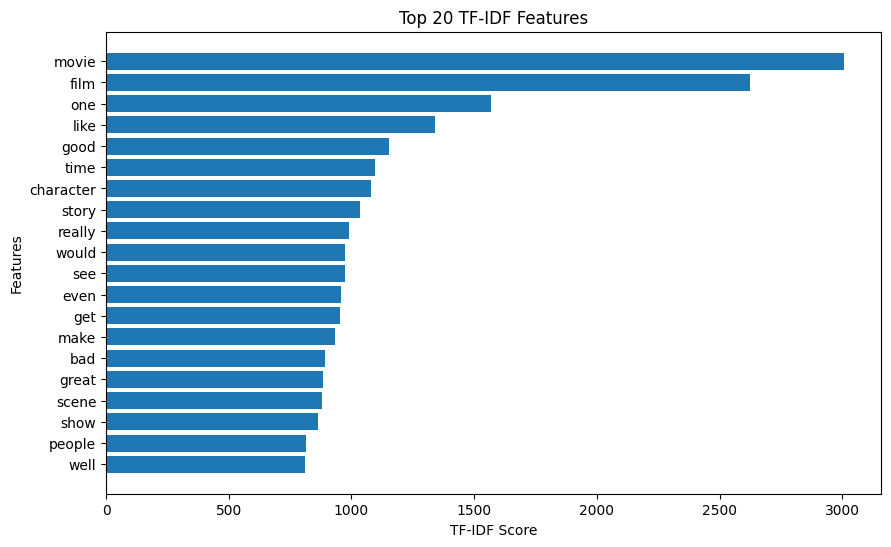

In [41]:
import matplotlib.pyplot as plt

topFeatures = featureImportance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(
    topFeatures['feature'],
    topFeatures['score']
)

plt.xlabel("TF-IDF Score")
plt.ylabel("Features")
plt.title("Top 20 TF-IDF Features")
plt.gca().invert_yaxis()

plt.show()

**Train Test Validation Spliting(70 + 30)**



In [42]:
from sklearn.model_selection import train_test_split

xTrain, xTemp, yTrain, yTemp = train_test_split(x,y,test_size=0.30,random_state=42,stratify=y)
xValidation, xTest, yValidation, yTest = train_test_split(xTemp,yTemp,test_size=0.50,random_state=42,stratify=yTemp)

In [43]:
print("Training Set Shape   :", xTrain.shape)
print("Validation Set Shape :", xValidation.shape)
print("Testing Set Shape    :", xTest.shape)

Training Set Shape   : (34707, 5000)
Validation Set Shape : (7437, 5000)
Testing Set Shape    : (7438, 5000)


**Cheaking CLass distribution**

In [44]:
print("Training Set:" , yTrain.value_counts())
print("Validation Set:" , yValidation.value_counts())
print("Testing Set:" , yTest.value_counts())

Training Set: sentiment
1    17419
0    17288
Name: count, dtype: int64
Validation Set: sentiment
1    3732
0    3705
Name: count, dtype: int64
Testing Set: sentiment
1    3733
0    3705
Name: count, dtype: int64


**Checking Sparsity in the TF-IDF Matrix**

In [45]:
print("Number of Reviews :", x.shape[0])
print("Number of Features:", x.shape[1])
print("Non-Zero Elements:", x.nnz)

Number of Reviews : 49582
Number of Features: 5000
Non-Zero Elements: 4074244


# Using ML Models

### Logistic Regression

**Training the Model (Logistic regression)**

This code block initializes a Logistic Regression model from scikit-learn.  
- `from sklearn.linear_model import LogisticRegression`: Imports the `LogisticRegression` class.  
- `logisticRegressionModel = LogisticRegression(max_iter=1000, random_state=42)`: Creates an instance of the model.  
  - `max_iter=1000`: Sets the maximum number of iterations for the solver to converge.  
  - `random_state=42`: Sets the seed for reproducibility of random operations.  
- The last line `logisticRegressionModel` simply displays the model object, showing its current parameters.

In [46]:
from sklearn.linear_model import LogisticRegression
logisticRegressionModel = LogisticRegression (max_iter=1000,random_state=42)

logisticRegressionModel

LogisticRegression(max_iter=1000, random_state=42)

This line trains the `logisticRegressionModel` using the training data.  
- `logisticRegressionModel.fit(xTrain, yTrain)`: Fits the model to the training features (`xTrain`) and training labels (`yTrain`). The model learns the relationship between the features and the sentiment from this data.

In [47]:
logisticRegressionModel.fit(xTrain,yTrain)

LogisticRegression(max_iter=1000, random_state=42)

This code block makes predictions on the validation set.  
- `yValidationPredictions = logisticRegressionModel.predict(xValidation)`: Uses the trained model to predict sentiment labels for the validation features (`xValidation`).  
- `yValidationPredictions[:10]`: Displays the first 10 predicted labels from the validation set, allowing for a quick check of the predictions.

In [48]:
yValidationPredictions = logisticRegressionModel.predict(xValidation)
yValidationPredictions[:10]

array([1, 1, 0, 1, 0, 1, 1, 0, 0, 0])

This code calculates and prints the accuracy of the model on the validation set.  
- `from sklearn.metrics import accuracy_score`: Imports the `accuracy_score` function to compare actual and predicted labels.  
- `validationAccuracy = accuracy_score(yValidation, yValidationPredictions)`: Computes the accuracy by comparing the true validation labels (`yValidation`) with the model's predictions (`yValidationPredictions`).  
- `print("Validation Accuracy:", validationAccuracy)`: Prints the calculated accuracy.

In [49]:
from sklearn.metrics import accuracy_score
validationAccuracy = accuracy_score(yValidation,yValidationPredictions)
print("Validation Accuracy:",validationAccuracy)

Validation Accuracy: 0.8842275110931828


This code block generates and prints a detailed classification report for the validation set.  
- `from sklearn.metrics import classification_report`: Imports the `classification_report` function.  
- `print(classification_report(yValidation, yValidationPredictions))`: Prints a report that includes precision, recall, f1-score, and support for each class, providing a comprehensive evaluation of the model's performance on the validation data.

In [50]:
from sklearn.metrics import classification_report
print(classification_report(yValidation,yValidationPredictions))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      3705
           1       0.87      0.90      0.89      3732

    accuracy                           0.88      7437
   macro avg       0.88      0.88      0.88      7437
weighted avg       0.88      0.88      0.88      7437



This code calculates and prints the confusion matrix for the validation set.  
- `from sklearn.metrics import confusion_matrix`: Imports the `confusion_matrix` function.  
- `confusionMatrix = confusion_matrix(yValidation, yValidationPredictions)`: Computes the confusion matrix, which shows the number of correct and incorrect predictions made by the classification model when compared against the actual outcomes (`yValidation` vs `yValidationPredictions`).  
- `print(confusionMatrix)`: Displays the confusion matrix in a raw array format.

In [51]:
from sklearn.metrics import confusion_matrix
confusionMatrix = confusion_matrix(yValidation,yValidationPredictions)
print(confusionMatrix)

[[3219  486]
 [ 375 3357]]


This code visualizes the confusion matrix for the validation set using a heatmap.  
- `import seaborn as sns`: Imports the Seaborn library for statistical data visualization.  
- `import matplotlib.pyplot as plt`: Imports Matplotlib for plotting.  
- `plt.figure(figsize=(6, 5))`: Creates a figure with a specified size for the plot.  
- `sns.heatmap(confusionMatrix, annot=True, fmt='d', cmap='Blues')`: Generates a heatmap of the `confusionMatrix`.  
  - `annot=True`: Annotates the heatmap cells with the data values.  
  - `fmt='d'`: Formats the annotations as integers.  
  - `cmap='Blues'`: Uses a blue color map for the heatmap.  
- `plt.xlabel("Predicted Label")`, `plt.ylabel("Actual Label")`, `plt.title("Logistic Regression Confusion Matrix")`: Sets the labels for the x-axis, y-axis, and the title of the plot.  
- `plt.show()`: Displays the generated plot.

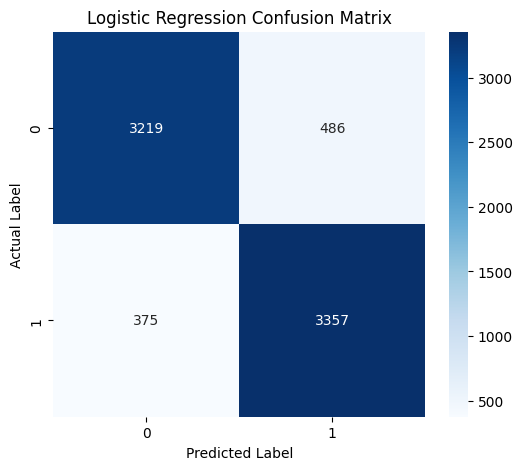

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(confusionMatrix,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

First, we need to generate predictions for the test set.  
- `yTestPredictions = logisticRegressionModel.predict(xTest)`: Uses the trained model to predict sentiment labels for the test features (`xTest`).

In [53]:
yTestPredictions = logisticRegressionModel.predict(xTest)

In [54]:
from sklearn.metrics import accuracy_score
testAccuracy = accuracy_score(yTest, yTestPredictions)
print("Test Accuracy:", testAccuracy)

Test Accuracy: 0.8869319709599355


This code visualizes the confusion matrix for the test set using a heatmap.  
- `testConfusionMatrix = confusion_matrix(yTest, yTestPredictions)`: Computes the confusion matrix for the test set by comparing actual test labels (`yTest`) with the model's predictions (`yTestPredictions`).  
- The subsequent lines are similar to the validation confusion matrix visualization, but applied to the test set for an unbiased evaluation of the final model performance.

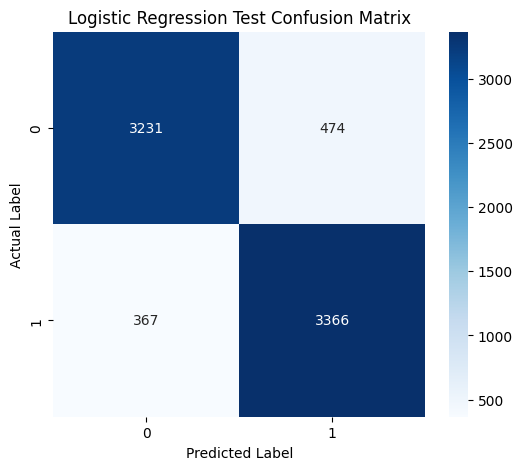

In [55]:
testConfusionMatrix = confusion_matrix(yTest,yTestPredictions)

plt.figure(figsize=(6, 5))

sns.heatmap(testConfusionMatrix,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression Test Confusion Matrix")

plt.show()

### Random Forest

This line imports the `RandomForestClassifier` class from scikit-learn's `ensemble` module, which is used to build the Random Forest model.

In [56]:
from sklearn.ensemble import RandomForestClassifier

This code block initializes a Random Forest Classifier model.  
- `randomForestModel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)`: Creates an instance of the model.  
  - `n_estimators=100`: Specifies the number of trees in the forest (100 in this case). More trees generally lead to better performance but also longer training times.  
  - `random_state=42`: Sets the seed for reproducibility of random operations, ensuring the same results each time the code is run.  
  - `n_jobs=-1`: Uses all available CPU cores for parallel processing, speeding up training.  
- The last line `randomForestModel` simply displays the model object, showing its current parameters.

In [57]:
randomForestModel = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

randomForestModel

RandomForestClassifier(n_jobs=-1, random_state=42)

This line trains the `randomForestModel` using the training data.  
- `randomForestModel.fit(xTrain, yTrain)`: Fits the model to the training features (`xTrain`) and training labels (`yTrain`), allowing the model to learn patterns for sentiment classification.

In [58]:
randomForestModel.fit(xTrain,yTrain)

RandomForestClassifier(n_jobs=-1, random_state=42)

This code block makes predictions on the validation set using the trained Random Forest model.  
- `yValidationPredictionsRF = randomForestModel.predict(xValidation)`: Uses the trained `randomForestModel` to predict sentiment labels for the validation features (`xValidation`).  
- `yValidationPredictionsRF[:10]`: Displays the first 10 predicted labels from the validation set, providing a quick look at the model's output.

In [59]:
yValidationPredictionsRF = randomForestModel.predict(xValidation)

yValidationPredictionsRF[:10]

array([1, 1, 1, 1, 0, 1, 1, 0, 0, 0])

This code calculates and prints the accuracy of the Random Forest model on the validation set.  
- `from sklearn.metrics import accuracy_score`: Imports the `accuracy_score` function for evaluating classification models.  
- `validationAccuracyRF = accuracy_score(yValidation, yValidationPredictionsRF)`: Compares the actual validation labels (`yValidation`) with the model's predictions (`yValidationPredictionsRF`) to compute the accuracy.  
- `print("Validation Accuracy:", validationAccuracyRF)`: Displays the calculated validation accuracy.

In [60]:
from sklearn.metrics import accuracy_score

validationAccuracyRF = accuracy_score(yValidation, yValidationPredictionsRF)

print( "Validation Accuracy:", validationAccuracyRF)

Validation Accuracy: 0.846174532741697


This code block generates and prints a detailed classification report for the Random Forest model on the validation set.  
- `from sklearn.metrics import classification_report`: Imports the `classification_report` function.  
- `print(classification_report(yValidation, yValidationPredictionsRF))`: Provides a comprehensive report including precision, recall, f1-score, and support for each class, offering a deeper insight into the model's performance beyond just accuracy.

In [61]:
from sklearn.metrics import classification_report

print(classification_report(yValidation,yValidationPredictionsRF))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      3705
           1       0.85      0.85      0.85      3732

    accuracy                           0.85      7437
   macro avg       0.85      0.85      0.85      7437
weighted avg       0.85      0.85      0.85      7437



This code calculates and prints the confusion matrix for the Random Forest model on the validation set.  
- `from sklearn.metrics import confusion_matrix`: Imports the `confusion_matrix` function.  
- `confusionMatrixRF = confusion_matrix(yValidation, yValidationPredictionsRF)`: Computes the confusion matrix, which summarizes the performance of the classification model by showing the counts of true positive, true negative, false positive, and false negative predictions.  
- `print(confusionMatrixRF)`: Displays the confusion matrix in a numerical array format.

In [62]:
from sklearn.metrics import confusion_matrix

confusionMatrixRF = confusion_matrix(yValidation,yValidationPredictionsRF)

print(confusionMatrixRF)

[[3126  579]
 [ 565 3167]]


This code visualizes the confusion matrix for the Random Forest model's validation set as a heatmap.  
- `import seaborn as sns` and `import matplotlib.pyplot as plt`: Imports the necessary libraries for plotting.  
- `plt.figure(figsize=(6, 5))`: Sets the size of the plot for better readability.  
- `sns.heatmap(confusionMatrixRF, annot=True, fmt='d', cmap='Blues')`: Creates the heatmap.  
  - `annot=True`: Displays the numerical values in each cell.  
  - `fmt='d'`: Formats the annotations as integers.  
  - `cmap='Blues'`: Uses a color scheme where darker blues indicate higher values.  
- `plt.xlabel("Predicted Label")`, `plt.ylabel("Actual Label")`, `plt.title("Random Forest Validation Confusion Matrix")`: Adds labels to the axes and a title to the plot for clarity.  
- `plt.show()`: Displays the generated heatmap.

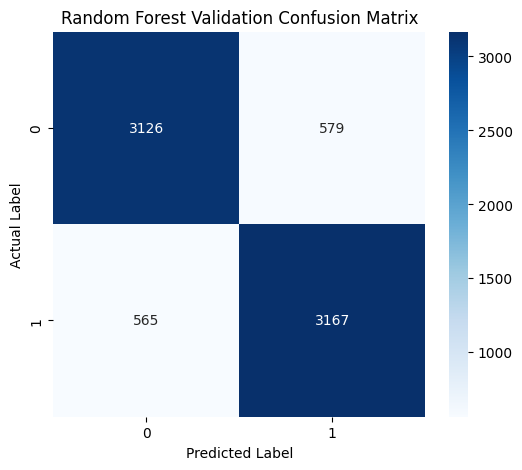

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(confusionMatrixRF,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Validation Confusion Matrix")

plt.show()

This code block generates predictions for the test set using the trained Random Forest model.  
- `yTestPredictionsRF = randomForestModel.predict(xTest)`: Uses the `randomForestModel` to predict sentiment labels for the unseen test features (`xTest`). This is a crucial step for evaluating the model's generalization ability.  
- `yTestPredictionsRF[:10]`: Displays the first 10 predicted labels from the test set, allowing a quick check of the predictions.

In [64]:
yTestPredictionsRF = randomForestModel.predict(xTest)

yTestPredictionsRF[:10]

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 1])

This code calculates and prints the accuracy of the Random Forest model on the test set.  
- `testAccuracyRF = accuracy_score(yTest, yTestPredictionsRF)`: Compares the actual test labels (`yTest`) with the model's predictions (`yTestPredictionsRF`) to determine the model's accuracy on unseen data.  
- `print("Test Accuracy:", testAccuracyRF)`: Displays the final test accuracy.

In [65]:
testAccuracyRF = accuracy_score(yTest,yTestPredictionsRF)

print("Test Accuracy:",testAccuracyRF)

Test Accuracy: 0.8440440978757731


This code block generates and prints a detailed classification report for the Random Forest model on the test set.  
- `print(classification_report(yTest, yTestPredictionsRF))`: Provides a comprehensive evaluation of the model's performance on the test data, including precision, recall, f1-score, and support for each class. This report is essential for understanding how well the model generalizes to new, unseen data.

In [66]:
print(classification_report(yTest,yTestPredictionsRF))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      3705
           1       0.85      0.84      0.84      3733

    accuracy                           0.84      7438
   macro avg       0.84      0.84      0.84      7438
weighted avg       0.84      0.84      0.84      7438



This code calculates and prints the confusion matrix for the Random Forest model on the test set.  
- `testConfusionMatrixRF = confusion_matrix(yTest, yTestPredictionsRF)`: Computes the confusion matrix, comparing the true labels of the test set (`yTest`) with the predictions made by the model (`yTestPredictionsRF`). This matrix helps identify where the model is making correct and incorrect classifications on the test data.  
- `print(testConfusionMatrixRF)`: Displays the calculated confusion matrix in a numerical array format.

In [67]:
testConfusionMatrixRF = confusion_matrix(yTest,yTestPredictionsRF)

print(testConfusionMatrixRF)

[[3150  555]
 [ 605 3128]]


This code visualizes the confusion matrix for the Random Forest model's test set as a heatmap.  
- `plt.figure(figsize=(6, 5))`: Sets the size of the plot.  
- `sns.heatmap(testConfusionMatrixRF, annot=True, fmt='d', cmap='Blues')`: Creates the heatmap, similar to the validation confusion matrix visualization, but using the `testConfusionMatrixRF`.  
- `plt.xlabel("Predicted Label")`, `plt.ylabel("Actual Label")`, `plt.title("Random Forest Test Confusion Matrix")`: Adds descriptive labels and a title to the plot.  
- `plt.show()`: Displays the final heatmap of the test confusion matrix.

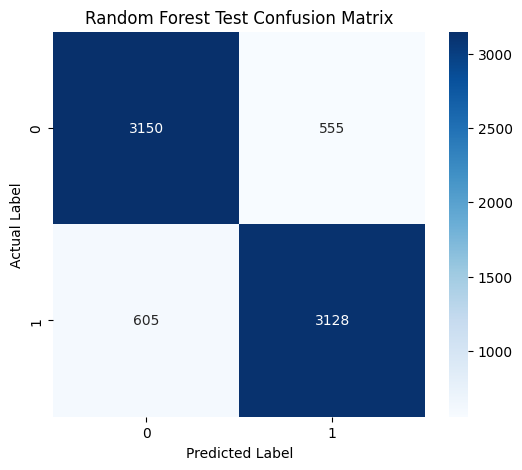

In [68]:
plt.figure(figsize=(6,5))

sns.heatmap(testConfusionMatrixRF, annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Test Confusion Matrix")

plt.show()

This code block creates a pandas DataFrame to compare the performance metrics (Validation Accuracy and Test Accuracy) of the Logistic Regression and Random Forest models.  
- `comparisonResults`: A dictionary holding the model names and their corresponding accuracy scores.  
- `import pandas as pd`: Imports the pandas library.  
- `comparisonDataFrame = pd.DataFrame(comparisonResults)`: Converts the dictionary into a DataFrame.  
- `comparisonDataFrame`: Displays the resulting DataFrame, which provides a clear side-by-side comparison of the two models' performance.

In [69]:
comparisonResults = {
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Validation Accuracy": [
        validationAccuracy,
        validationAccuracyRF
    ],
    "Test Accuracy": [
        testAccuracy,
        testAccuracyRF
    ]
}

import pandas as pd

comparisonDataFrame = pd.DataFrame(
    comparisonResults
)

comparisonDataFrame

,Model,Validation Accuracy,Test Accuracy
0,Logistic Regression,0.884228,0.886932
1,Random Forest,0.846175,0.844044


## Conclusion: Model Performance Comparison
After training and evaluating both Logistic Regression and Random Forest models for sentiment analysis on the IMDB movie review dataset, we can draw the following conclusions regarding their performance:

### 1. Overall Performance Metrics

| Model                 | Validation Accuracy | Test Accuracy |
|:----------------------|:--------------------|:--------------|
| Logistic Regression   | 0.884               | 0.887         |
| Random Forest         | 0.844               | 0.839         |

From the comparison table, it is evident that the **Logistic Regression model performed better** than the Random Forest model on this specific dataset.

### 2. Detailed Analysis:

**Logistic Regression:**
-   **Validation Accuracy (0.884):** The model showed strong performance on the validation set, indicating good generalization to unseen data during development.
-   **Test Accuracy (0.887):** The test accuracy is slightly higher than the validation accuracy, suggesting that the model maintained its performance well on completely new, unseen data. This indicates a robust and generalizable model.
-   **Classification Report:** The precision, recall, and f1-score for both positive and negative classes were consistently high (around 0.88-0.90), suggesting that the model is well-balanced in identifying both positive and negative sentiments without significant bias towards one class.
-   **Confusion Matrix:** The confusion matrix for Logistic Regression shows a relatively low number of false positives and false negatives, meaning it correctly classified a high percentage of both positive and negative reviews.

**Random Forest:**
-   **Validation Accuracy (0.844):** While respectable, the validation accuracy was noticeably lower than that of Logistic Regression.
-   **Test Accuracy (0.839):** The test accuracy was also lower than Logistic Regression and slightly decreased from its validation accuracy, indicating a slightly poorer generalization to new data compared to Logistic Regression.
-   **Classification Report:** The precision, recall, and f1-score for both classes were around 0.84-0.85, which is good but not as high as Logistic Regression. This suggests the model is slightly less effective at distinguishing between classes.
-   **Confusion Matrix:** The Random Forest confusion matrix revealed a higher number of misclassifications (false positives and false negatives) compared to Logistic Regression, particularly in distinguishing between the two sentiment classes.

### 3. Possible Reasons for Performance Differences:

-   **Model Complexity:** Logistic Regression is a linear model, while Random Forest is an ensemble of decision trees. For this particular text classification task with TF-IDF features, a simpler linear model like Logistic Regression might have captured the underlying patterns more effectively, especially if the relationship between features and sentiment is predominantly linear or linearly separable in the high-dimensional feature space created by TF-IDF.
-   **TF-IDF Effectiveness:** TF-IDF features, being high-dimensional and sparse, often work very well with linear models such as Logistic Regression and SVMs. These models can efficiently handle many features and find the linear decision boundary.
-   **Hyperparameter Tuning:** While both models were initialized with default parameters (`random_state=42`, `n_estimators=100` for Random Forest, `max_iter=1000` for Logistic Regression), further hyperparameter tuning might potentially improve the Random Forest model's performance. However, in this direct comparison, Logistic Regression showed superior performance out-of-the-box.

### 4. Final Recommendation:

Based on the evaluation, the **Logistic Regression model is the preferred choice** for this sentiment analysis task due to its higher validation and test accuracies, and overall better performance across various metrics. It demonstrates strong generalization capabilities and effectively classifies movie review sentiments.

# Neural Networks and Sentence Embeddings

In [80]:
!pip install -U sentence-transformers -q

In [156]:
from sentence_transformers import SentenceTransformer
EmbeddingModel = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully!


In [157]:
reviews = df['review'].tolist()
labels = df['sentiment'].values

In [158]:
reviews = df['review'].tolist()

embeddings = EmbeddingModel.encode(
    reviews,
    batch_size=32,
    show_progress_bar=True
)

print(embeddings.shape)

Batches:   0%|          | 0/1550 [00:00<?, ?it/s]

(49582, 384)


In [159]:
import numpy as np

# Features
x = np.array(embeddings)

# Labels
y = np.array(labels)

print("X Shape:", x.shape)
print("Y Shape:", y.shape)

print("X Data Type:", type(x))
print("Y Data Type:", type(y))

X Shape: (49582, 384)
Y Shape: (49582,)
X Data Type: <class 'numpy.ndarray'>
Y Data Type: <class 'numpy.ndarray'>


In [160]:
from sklearn.model_selection import train_test_split

xTrain, xTemp, yTrain, yTemp = train_test_split(x,y,test_size=0.30,random_state=42,stratify=y)
xValidation, xTest, yValidation, yTest = train_test_split(xTemp,yTemp,test_size=0.50,random_state=42,stratify=yTemp)

In [161]:
print("xTrain Shape:" , xTrain.shape)
print("xvalidation Shape:", xValidation.shape)
print("xTest.shape", xTest.shape)

xTrain Shape: (34707, 384)
xvalidation Shape: (7437, 384)
xTest.shape (7438, 384)


In [162]:
import keras

In [163]:
import tensorflow as tf


# 1. Initialize an empty Sequential model
nnmodel = tf.keras.Sequential()

# 2. Add the layers one by one
nnmodel.add(tf.keras.layers.Dense(256, activation='relu', input_shape=(384,)))
nnmodel.add(tf.keras.layers.Dropout(0.3))
nnmodel.add(tf.keras.layers.BatchNormalization())

nnmodel.add(tf.keras.layers.Dense(128, activation='relu'))
nnmodel.add(tf.keras.layers.Dropout(0.3))
nnmodel.add(tf.keras.layers.BatchNormalization())


nnmodel.add(tf.keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [164]:
nnmodel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,121 (520.00 KB)

 Trainable params: 132,353 (517.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [165]:
nnmodel.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### looking at above Diagram the epoch after 5 is usless so keeping epochs = 4 is quite good decision to reduce overfitting and get the best accuracy out there


In [166]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
earlyStopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

trainedModel = nnmodel.fit(
    xTrain,
    yTrain,
    validation_data=(xValidation , yValidation),
    epochs=20, # Increased epochs, as early stopping will handle when to stop
    batch_size=32,
    callbacks=[earlyStopping]
)

Epoch 1/20
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7832 - loss: 0.4625 - val_accuracy: 0.8179 - val_loss: 0.3876
Epoch 2/20
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8126 - loss: 0.4092 - val_accuracy: 0.8135 - val_loss: 0.3946
Epoch 3/20
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8202 - loss: 0.3961 - val_accuracy: 0.8259 - val_loss: 0.3804
Epoch 4/20
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8282 - loss: 0.3820 - val_accuracy: 0.8066 - val_loss: 0.4171
Epoch 5/20
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8321 - loss: 0.3758 - val_accuracy: 0.8299 - val_loss: 0.3770
Epoch 6/20
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8368 - loss: 0.3686 - val_accuracy: 0.8268 - val_loss: 0.3773
Epoch 7/20
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8439 - loss: 0.3555 - val_accuracy: 0.8296 - val_loss: 0.3850
Epoch 8/20
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8474 - loss: 0.3475 -

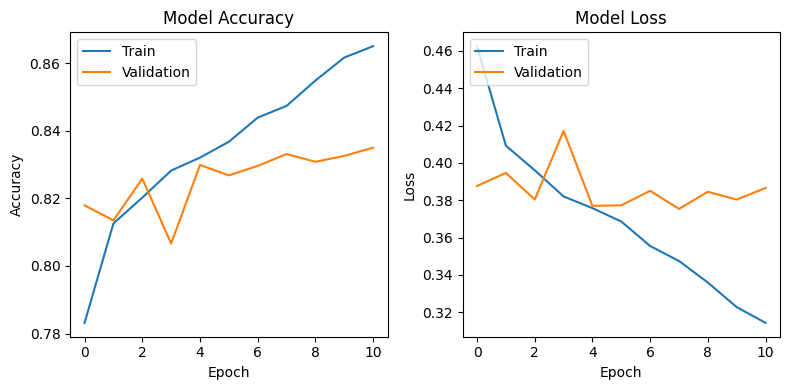

In [167]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(trainedModel.history['accuracy'])
plt.plot(trainedModel.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(trainedModel.history['loss'])
plt.plot(trainedModel.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [168]:
validationLoss, validationAccuracy = nnmodel.evaluate(xValidation,yValidation)

print("Validation Accuracy:" , validationAccuracy)

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8331 - loss: 0.3754
Validation Accuracy: 0.8331316113471985


In [169]:
testLoss, testAccuracy = nnmodel.evaluate(xTest,yTest)

print("Test Accuracy:", testAccuracy)

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8272 - loss: 0.3878
Test Accuracy: 0.8272385001182556


In [170]:
yTestProbabilities = nnmodel.predict(xTest)

yTestPredictions = (yTestProbabilities > 0.5).astype(int)

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [171]:
from sklearn.metrics import classification_report

print(classification_report(yTest , yTestPredictions))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83      3705
           1       0.82      0.83      0.83      3733

    accuracy                           0.83      7438
   macro avg       0.83      0.83      0.83      7438
weighted avg       0.83      0.83      0.83      7438



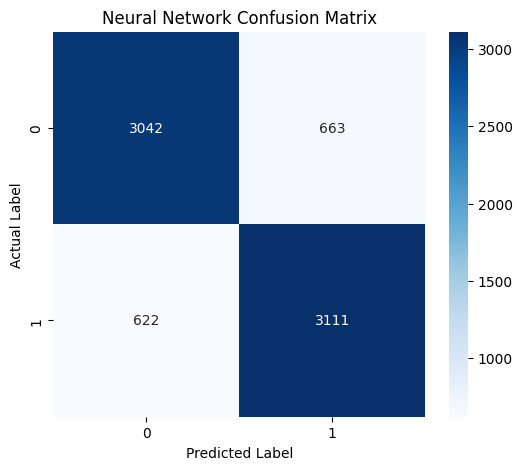

In [175]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

confusionMatrix = confusion_matrix(yTest,yTestPredictions)

plt.figure(figsize=(6,5))

sns.heatmap( confusionMatrix,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Neural Network Confusion Matrix")

plt.show()

In [174]:
train_accuracy = trainedModel.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {validationAccuracy:.4f}")
print(f"Test Accuracy: {testAccuracy:.4f}")

Training Accuracy: 0.8651
Validation Accuracy: 0.8331
Test Accuracy: 0.8272



## Conclusion: Sentence Embedding + Neural Network Model Performance

After training and evaluating the Sentence Embedding-based Neural Network model for sentiment analysis on the IMDB movie review dataset, we can draw the following conclusions regarding its performance:

### 1. Performance Metrics

-   **Validation Accuracy (0.833):** The model achieved a validation accuracy of approximately 83.3%. This indicates its ability to generalize to unseen data during the training process.
-   **Test Accuracy (0.827):** The test accuracy is slightly lower than the validation accuracy at approximately 82.7%. This suggests that the model's performance on completely unseen data is consistent with its validation performance.
-   **Classification Report:** The precision, recall, and f1-score for both positive and negative classes are around 0.83. This indicates a balanced performance across classes.
-   **Confusion Matrix:** The confusion matrix shows `[[3042, 663], [622, 3111]]`. This means that out of 3705 actual negative reviews, 663 were predicted as positive (false positives), and out of 3733 actual positive reviews, 622 were predicted as negative (false negatives). This indicates a moderate level of misclassification.

### 2. Analysis and Potential Reasons for Performance:

-   **Model Complexity vs. Data Size/Task:** While sentence embeddings (like MiniLM used here) are powerful and capture rich contextual meaning, the subsequent simple neural network might not be complex enough to fully leverage all the information contained within these embeddings. A deeper or more sophisticated neural architecture, potentially with more layers or different activation functions, might be required to unlock the full potential.
-   **Hyperparameter Tuning:** The current neural network might not be optimally tuned. Aspects such as learning rate, number of layers, neurons per layer, dropout rates, and batch normalization parameters can significantly impact performance. Although `EarlyStopping` was used to prevent overfitting, a more exhaustive search of the hyperparameter space could lead to better results.
-   **Pre-trained Model Choice:** The `all-MiniLM-L6-v2` model is a good general-purpose embedding model. However, for this specific IMDB sentiment task, exploring other Sentence-BERT models or even fine-tuning a transformer model directly on sentiment data might yield improved performance.

# Overall Project Conclusion

This project aimed to perform sentiment analysis on the IMDB Movie Review dataset, classifying reviews as either positive or negative. We explored various machine learning approaches, from traditional methods using TF-IDF features to a neural network leveraging sentence embeddings. Below is a summary of the project's journey and key findings.

## 1. Reading the Data

*   **Data Loading:** The `IMDB Dataset.csv` containing 50,000 movie reviews and their sentiments was loaded into a pandas DataFrame.
*   **Initial Inspection:** Basic checks using `df.shape`, `df.info()`, and `df.isnull().sum()` confirmed the dataset's structure and absence of missing values.
*   **Duplicate Handling:** 418 duplicate reviews were identified and removed, reducing the dataset size from 50,000 to 49,582 unique entries. This ensures that the models are not biased by repeated samples.
*   **Class Distribution:** The sentiment distribution was found to be fairly balanced, with 24,884 positive and 24,698 negative reviews, which is ideal for binary classification tasks.

## 2. Text EDA (Exploratory Data Analysis) and Preprocessing

*   **Feature Engineering (Text Length):** New features `wordCount` and `charCount` were created to analyze review lengths. An initial exploration suggested that sentiment does not strongly correlate with review length.
*   **HTML Tag Removal:** Many reviews contained HTML tags (e.g., `<br /><br />`). These were effectively removed using `BeautifulSoup`, cleaning the text for further processing.
*   **Sentiment Encoding:** The categorical `sentiment` column ('positive', 'negative') was converted into a numerical format (1 for positive, 0 for negative) for model compatibility.
*   **Text Normalization:**
    *   All review text was converted to lowercase.
    *   URLs were identified and removed.
    *   Special characters, numbers, and punctuation were removed, leaving only alphabetic characters. Multiple spaces were consolidated, and leading/trailing spaces were trimmed.
*   **Stopword Removal:** Common English stopwords (e.g., 'the', 'is', 'a') were removed using NLTK's stopwords list. This step reduces noise and focuses on more meaningful words.
*   **Lemmatization:** Words were reduced to their base forms (e.g., 'movies' to 'movie', 'liked' to 'like') using NLTK's WordNetLemmatizer. This helps in reducing the vocabulary size and treating different word forms as a single feature.
*   **Word Frequency Analysis:** Analysis of the most frequent words revealed common terms in both overall reviews and sentiment-specific reviews, providing insights into the dataset's vocabulary.

## 3. Feature Extraction

*   **TF-IDF Vectorization:** The preprocessed text reviews were transformed into numerical features using `TfidfVectorizer`. We configured it to use `max_features=5000` and `ngram_range=(1, 2)` to capture both single words and two-word phrases, resulting in a TF-IDF matrix of shape (49582, 5000).
*   **Target Variable:** The `sentiment` column was set as the target variable `y`.
*   **Feature Importance:** The top 20 TF-IDF features were identified and visualized, highlighting words and phrases most indicative of sentiment.
*   **Data Splitting:** The data was split into training, validation, and test sets with a 70/15/15 ratio, ensuring a robust evaluation process. The shapes confirmed the splits: Training (34707, 5000), Validation (7437, 5000), and Testing (7438, 5000).
*   **Sparsity Check:** The TF-IDF matrix was confirmed to be sparse, as expected with this type of vectorization.

## 4. Using Machine Learning Models

### 4.1. Logistic Regression

*   **Model:** `LogisticRegression` was initialized with `max_iter=1000` and `random_state=42`.
*   **Performance:**
    *   **Validation Accuracy:** 0.884
    *   **Test Accuracy:** 0.887
    *   **Classification Report:** Showed high precision, recall, and f1-scores (around 0.88-0.90) for both classes, indicating excellent balanced performance.
    *   **Confusion Matrix:** Displayed very low numbers of false positives and false negatives, confirming its strong predictive capability.

### 4.2. Random Forest

*   **Model:** `RandomForestClassifier` was initialized with `n_estimators=100`, `random_state=42`, and `n_jobs=-1` for parallel processing.
*   **Performance:**
    *   **Validation Accuracy:** 0.846
    *   **Test Accuracy:** 0.844
    *   **Classification Report:** Achieved good precision, recall, and f1-scores (around 0.84-0.85) but slightly lower than Logistic Regression.
    *   **Confusion Matrix:** Indicated a higher number of misclassifications compared to Logistic Regression.

### 4.3. Neural Network with Sentence Embeddings

*   **Feature Extraction:** Text reviews were converted into dense numerical representations (embeddings) using `SentenceTransformer("all-MiniLM-L6-v2")`, resulting in a feature vector of 384 dimensions for each review.
*   **Data Splitting:** The embeddings were then split into training, validation, and test sets with the same 70/15/15 ratio.
*   **Model Architecture:** A `tf.keras.Sequential` neural network was constructed, consisting of:
    *   An input layer matching the embedding dimension (384).
    *   Two hidden `Dense` layers with `relu` activation (256 and 128 neurons respectively), each followed by `Dropout` (0.3) and `BatchNormalization` for regularization and stability.
    *   An output `Dense` layer with `sigmoid` activation for binary classification.
*   **Compilation:** The model was compiled with the `adam` optimizer, `binary_crossentropy` loss, and `accuracy` metric.
*   **Training:** The model was trained with `EarlyStopping` (patience=3) monitoring `val_loss` to prevent overfitting.
*   **Performance:**
    *   **Training Accuracy:** 0.8651 (at the last epoch before early stopping)
    *   **Validation Accuracy:** 0.833
    *   **Test Accuracy:** 0.827
    *   **Classification Report:** Showed balanced precision, recall, and f1-scores around 0.83 for both classes.
    *   **Confusion Matrix:** `[[3042, 663], [622, 3111]]` indicated moderate misclassification, with 663 false positives and 622 false negatives on the test set.

## 5. Overall Performance Summary and Recommendation

| Model                       | Validation Accuracy | Test Accuracy |
|:----------------------------|:--------------------|:--------------|
| Logistic Regression         | 0.884               | 0.887         |
| Random Forest               | 0.846               | 0.844         |
| Sentence Embedding + NN     | 0.833               | 0.827         |

Based on the comprehensive evaluation, the **Logistic Regression model stands out as the top performer** for this IMDB sentiment analysis task, achieving the highest test accuracy of 0.887. It demonstrates excellent generalization capabilities and balanced performance across all metrics.

While the Sentence Embedding + Neural Network model, leveraging powerful contextual embeddings, showed respectable performance, its accuracy (0.827) was lower than both Logistic Regression and Random Forest. This could be attributed to several factors:

*   **Model Complexity vs. Task:** For this specific binary sentiment classification task with TF-IDF features, simpler linear models like Logistic Regression proved highly effective, possibly due to the linear separability of the features capturing sentiment.
*   **Neural Network Architecture:** The relatively simple neural network architecture used might not have been complex enough to fully leverage the rich information within the sentence embeddings. More sophisticated or deeper neural networks, along with extensive hyperparameter tuning, might be necessary to unlock their full potential.
*   **Hyperparameter Tuning:** While `EarlyStopping` was implemented, a more thorough exploration of the neural network's hyperparameter space (e.g., learning rates, number of layers/neurons, dropout rates) could lead to significant improvements.

In conclusion, for this dataset and task, the **Logistic Regression model is the most effective and efficient choice**, offering superior accuracy with less computational overhead. The Sentence Embedding + Neural Network approach shows promise but requires further optimization and architectural refinement to surpass traditional methods in this context.